<a href="https://colab.research.google.com/github/aceholland/Boston-House-Price-Prediction_-ML-_-Linear-Regression/blob/main/Boston_House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Boston House Price Prediction Project:

In this project you will work on developing an end to end machine learning project using linear regression. We will be doing an extensive data visualization, we will perform data feature engineering, we will also see how we can select features based on correlation of the features.



Step 1: Importing libraries

In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

Step 2: Loading the dataset

We import the dataset into a pandas DataFrame.

In [31]:
df = pd.read_csv("out.csv")

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,SalePrice
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


Step 3: Basic information

This gives:

1. Number of rows
2. Number of columns
3. Data types
4. Statistical summary

In [32]:
df.shape


(506, 14)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CRIM       506 non-null    float64
 1   ZN         506 non-null    float64
 2   INDUS      506 non-null    float64
 3   CHAS       506 non-null    float64
 4   NOX        506 non-null    float64
 5   RM         506 non-null    float64
 6   AGE        506 non-null    float64
 7   DIS        506 non-null    float64
 8   RAD        506 non-null    float64
 9   TAX        506 non-null    float64
 10  PTRATIO    506 non-null    float64
 11  B          506 non-null    float64
 12  LSTAT      506 non-null    float64
 13  SalePrice  506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [34]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,SalePrice
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


Step 4: Check for missing values

In [35]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


Step 5: Check for duplicated values

In [36]:
df.duplicated().sum()

np.int64(0)

Step 6: Correlation heatmap

What is Correlation?
Correlation tells us how strongly two variables are related.

This helps identify:

1. Highly correlated features
2. Relationship with target variable

Red means positive correlation and blue means negative correlation, white is near zero correlation.

What is df.corr()?
It calculates Pearson Correlation between every pair of numerical columns. The output is a correlation matrix.

This shows the Pearson Correlation.

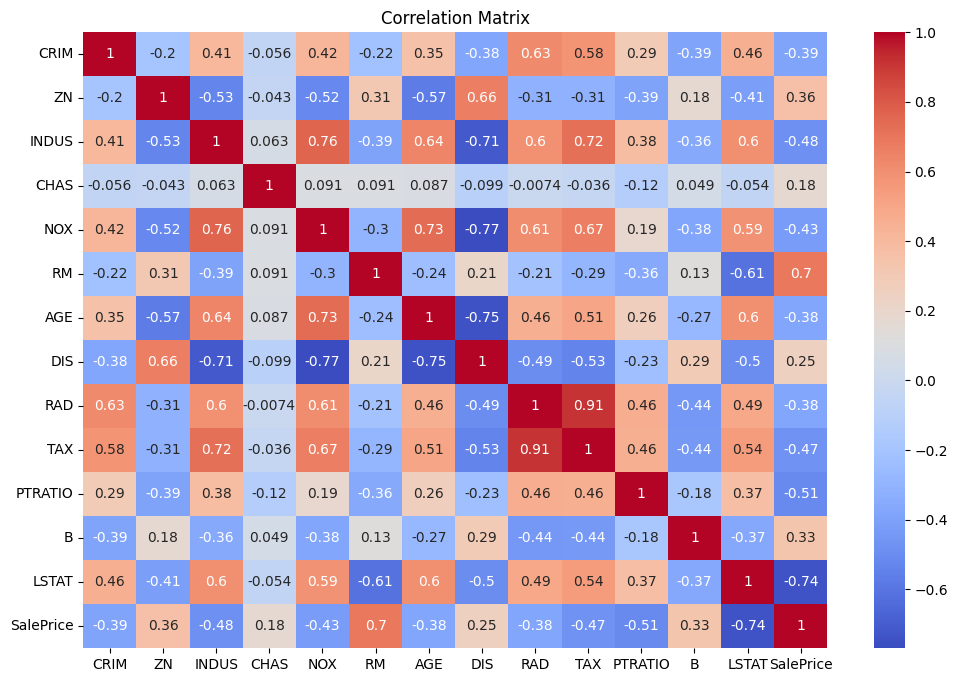

In [37]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

Step 7: Shows how house prices are distributed.

Here histogram shows the frequency of occurence.

KDE
kde=True
adds a smooth curve over the histogram.
It helps identify the underlying distribution more clearly.

Look for:

Normal distribution,
Right skew,
Left skew,
Multiple peaks.

If highly skewed , we apply this before training:
np.log()

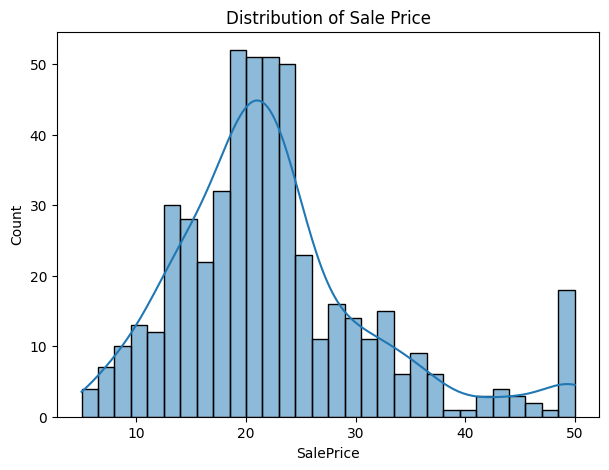

In [38]:
plt.figure(figsize=(7,5))

sns.histplot(df["SalePrice"], bins=30, kde=True)

plt.title("Distribution of Sale Price")

plt.show()

Step 8: Boxplot

Boxplot purpose is to show outliers.

What are outliers?
Outliers are values larger or smaller than the other datas. So every other data is shown as boxes , and outlier is shown as a star.

Outliers need to be removed:

They may:

1. reduce accuracy
2. affect regression line
3. increase error

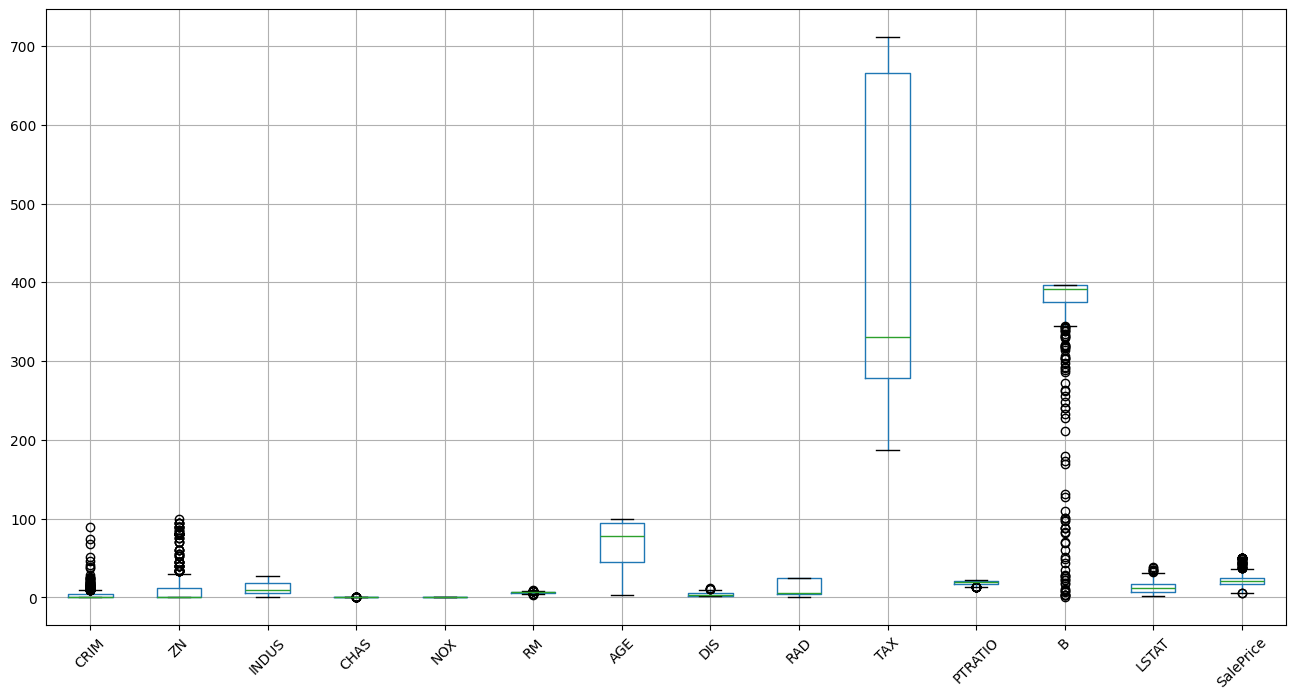

In [39]:
plt.figure(figsize=(16,8))

df.boxplot(rot=45)

plt.show()

Step 9: Pair Plot

Pair Plot compares every feature against every feature.

Why useful?

Shows

1. Linear relationships
2. Clusters
3. Outliers
4. Trends

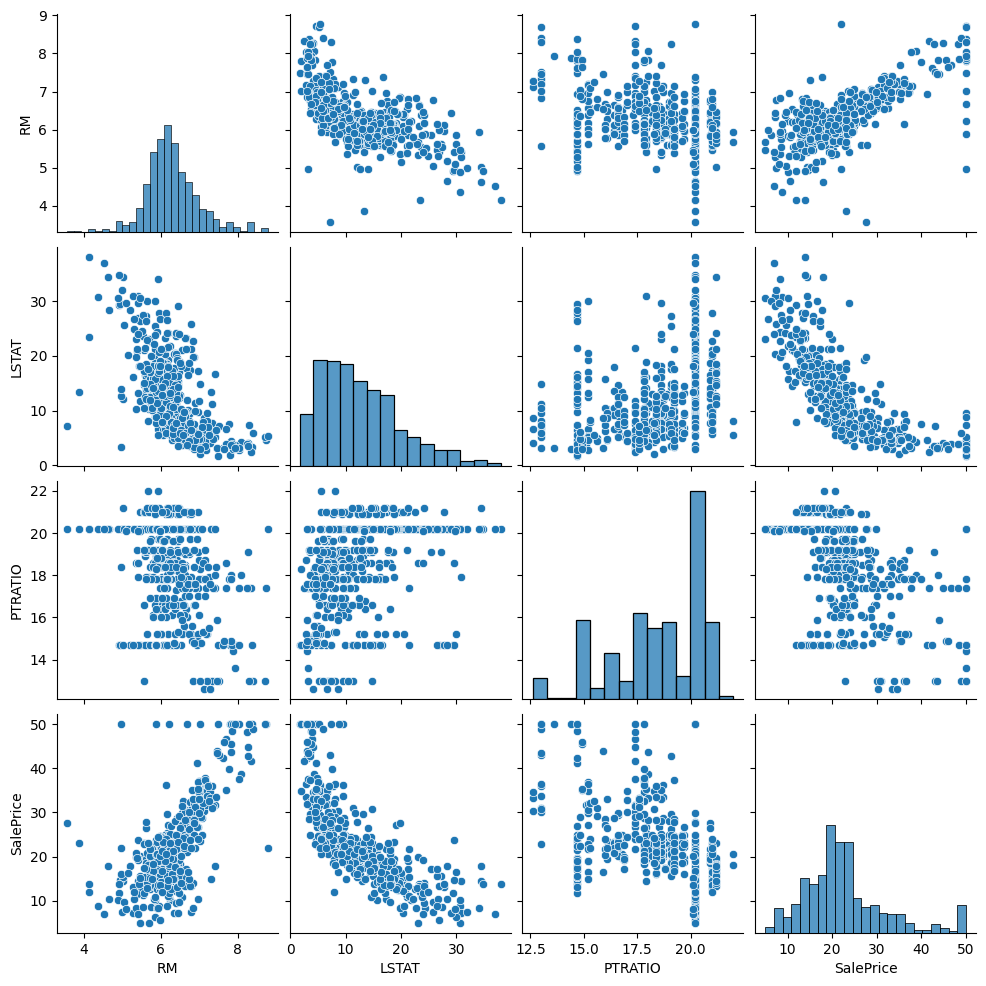

In [40]:
sns.pairplot(
    df[["RM","LSTAT","PTRATIO","SalePrice"]]
)

plt.show()

Step 10: Scatter Plot

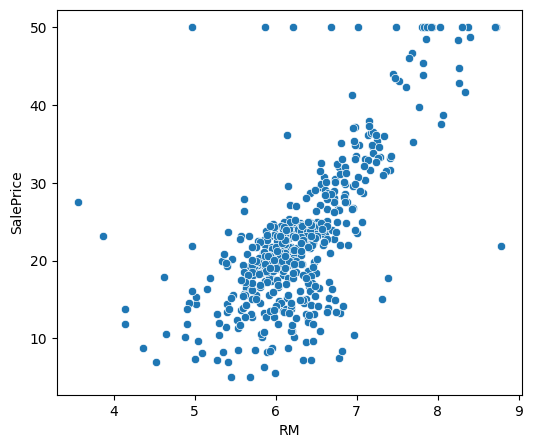

In [41]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    x="RM",
    y="SalePrice",
    data=df
)

plt.show()

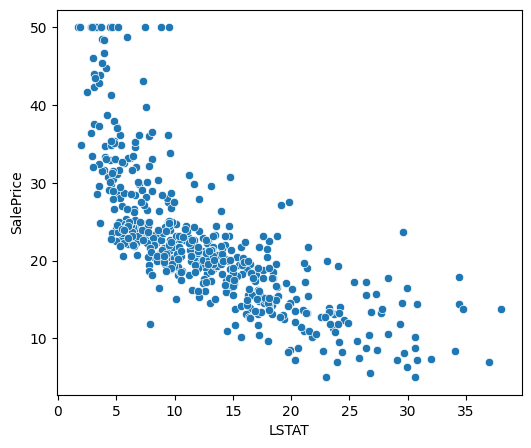

In [42]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    x="LSTAT",
    y="SalePrice",
    data=df
)

plt.show()

Step 11: Feature Engineering

Feature Engineering means improving the dataset before training.

Typical tasks include:

1. Handling missing values
2. Encoding categorical variables
3. Scaling features
4. Creating new features
5. Removing unnecessary columns

In your dataset:

No missing values
All features are numeric
No categorical variables

So, very little preprocessing is needed

Step 12: Feature Selection Using Correlation

This extracts the correlation of every feature with the target (SalePrice) and sorts them from highest to lowest.

Interpretation
1. Positive values: As the feature increases, the sale price tends to increase.
2. Negative values: As the feature increases, the sale price tends to decrease.
3. Values close to 0: Little or no linear relationship.



1. |correlation| > 0.7 → Strong relationship
2. 0.5–0.7 → Moderate relationship
3. < 0.3 → Weak relationship

Why do we perform all these steps before training?

The purpose of Exploratory Data Analysis (EDA) is to understand the dataset before building a model.

Each step answers a different question.



| Step                | Purpose                                                     |
| ------------------- | ----------------------------------------------------------- |
| Check duplicates    | Is the same data repeated?                                  |
| Correlation heatmap | Which features are related to each other and to the target? |
| Histogram           | How is the target variable distributed?                     |
| Boxplot             | Are there outliers?                                         |
| Pairplot            | Are relationships linear?                                   |
| Scatter plots       | How does each important feature affect the target?          |
| Feature engineering | Is preprocessing needed?                                    |
| Feature selection   | Which features should be used for prediction?               |


In [43]:
corr = df.corr()["SalePrice"].sort_values(ascending=False)

corr

,SalePrice
SalePrice,1.000000
RM,0.695360
ZN,0.360445
B,0.333461
DIS,0.249929
CHAS,0.175260
AGE,-0.376955
RAD,-0.381626
CRIM,-0.388305
NOX,-0.427321


Step 13: Define Features (X) and Target Variable (y)

What are Features?

Features are the independent variables or input variables that help predict the target.

What does this code do?
X = df.drop("SalePrice", axis=1)

It removes the SalePrice column.

Remaining columns become the input features.

What is axis=1?

Pandas has two axes.

axis=0 → Rows

axis=1 → Columns

Since SalePrice is a column, we write axis=1

The machine learns the relationship between inputs and output.

Why separate X and y?

Machine learning models always require

Inputs → X

Output → y

Without separating them, the algorithm wouldn't know "What should I predict?"

In [44]:
X = df.drop("SalePrice", axis=1)

y = df["SalePrice"]

The machine learns the relationship between inputs and output.

Why separate X and y?

Machine learning models always require

Inputs → X

Output → y

Without separating them, the algorithm wouldn't know "What should I predict?"

Why split the dataset?

Imagine you have 100 houses.

If you train and test on the same 100 houses,

the model may simply memorize the answers instead of learning patterns.

To properly evaluate performance, we divide the data:

Training set → used to teach the model.
Testing set → used to check how well it performs on unseen data.

Suppose there are 500 houses.

80%-Training-400 houses-Model learns
20%-Testing-100 houses

Model predicts then Compare prediction with actual prices

What is random_state=42?

The dataset is shuffled before splitting.

Without a fixed random state:

Run 1-Different train/test split

Run 2-Different split again

This leads to different results each time.

Using: random_state=42
ensures the split is the same every time, making the experiment reproducible.

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Step 15: Build the Linear Regression Model

What is Linear Regression?

Linear Regression finds the best-fit line that describes the relationship between the input features and the target.

The general equation is:

SalePrice = b₀ + b₁X₁ + b₂X₂ + ... + bₙXₙ

Where:

1. b₀ = Intercept
2. b₁, b₂, ... = Coefficients (weights)
3. X₁, X₂, ... = Features such as RM, LSTAT, TAX

What does LinearRegression() do?

It creates an empty regression model.

At this point, the model has not learned anything.

What does fit() do?
model.fit(X_train, y_train)

This is the learning step.

The model:
1. Reads the training data.
2. Finds the best coefficients.
3. Learns how each feature affects SalePrice.

In [46]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

Step 16: Make predictions

What happens here?

The model uses the learned coefficients to predict prices for the test houses.

In [47]:
y_pred = model.predict(X_test)

Step 17: Model Evaluation

1. MAE: Average of abs (Actual - Predicted)
A smaller MAE indicates more accurate predictions.

2. Mean Squared Error (MSE): Avergae of square of (Actual-Predicted)

Why square the errors?
Squaring penalizes large mistakes more heavily.

For example:

Error = 10 → Squared Error = 100

This makes the model sensitive to large prediction errors


In [48]:
mae = mean_absolute_error(y_test, y_pred)

print(mae)

3.189091965887837


In [49]:
mse = mean_squared_error(y_test, y_pred)

print(mse)

24.291119474973478


RMSE= sq root of MSE
Why use RMSE?

MSE is measured in squared units.

Taking the square root converts it back to the original unit (house price), making it easier to interpret.

Lower RMSE indicates better performance.

In [50]:
rmse = np.sqrt(mse)

print(rmse)

4.928602182665332


R² Score (Coefficient of Determination)

What does R² measure?

R² tells us how much of the variation in SalePrice is explained by the model.

| R² Score | Meaning                                                 |
| -------- | ------------------------------------------------------- |
| 1.00     | Perfect prediction                                      |
| 0.95     | 95% of the variation is explained                       |
| 0.80     | Very good model                                         |
| 0.50     | Moderate model                                          |
| 0.00     | No predictive power                                     |
| Negative | Model performs worse than simply predicting the average |


For example:

R² = 0.87

This means the model explains 87% of the variation in house prices.

In [51]:
r2 = r2_score(y_test, y_pred)

print(r2)

0.6687594935356326


Step 18: Actual vs Predicted Plot

Each point represents one house.

X-axis: Actual Sale Price
Y-axis: Predicted Sale Price

The red diagonal line represents perfect predictions.

If points lie close to the red line, the model is making accurate predictions.

If points are scattered far away, prediction errors are larger.

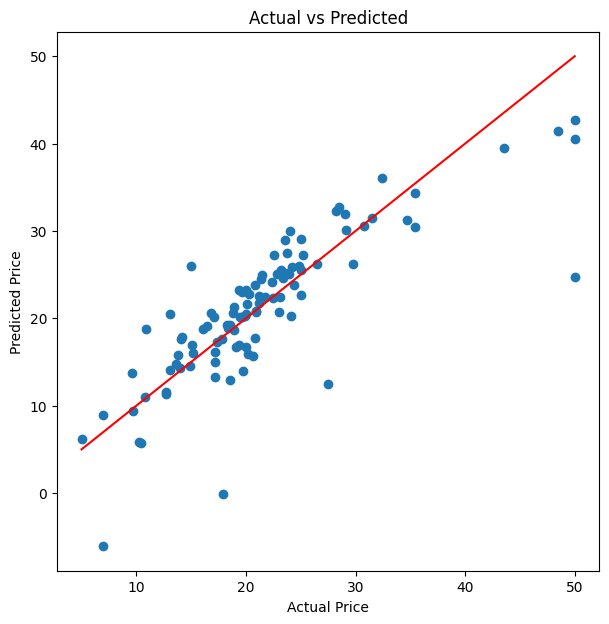

In [52]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    color="red"
)

plt.show()

Step 19: Residual Analysis

Residual = Actual Price − Predicted Price

Residuals show how much the model's predictions differ from the true values.

Interpretation

A good Linear Regression model should have residuals:

Centered around 0
Roughly normally distributed
Without obvious patterns

This indicates that prediction errors are random and the model fits the data well.

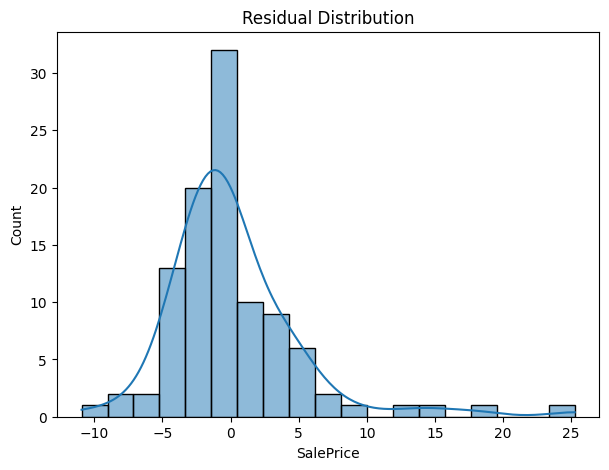

In [53]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

Step 20: Feature Importance (Coefficients)

Each coefficient indicates how the predicted SalePrice changes when a feature increases by one unit, while keeping all other features constant.

Positive coefficient: Increasing the feature tends to increase SalePrice.
Negative coefficient: Increasing the feature tends to decrease SalePrice.

For example:

A positive coefficient for RM means houses with more rooms generally have higher prices.
A negative coefficient for LSTAT means higher LSTAT values are associated with lower house prices

In [54]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
5,RM,4.438835
3,CHAS,2.784438
8,RAD,0.262430
2,INDUS,0.040381
1,ZN,0.030110
11,B,0.012351
6,AGE,-0.006296
9,TAX,-0.010647
0,CRIM,-0.113056
12,LSTAT,-0.508571


Conclusion:

In this project, we:

1. Explored and understood the dataset through EDA.
2. Verified that there were no duplicate or missing values.
3. Used visualizations such as histograms, boxplots, scatter plots, pair plots, and a correlation heatmap to understand the relationships between variables.
4. Selected useful features based on their correlation with the target variable.
5. Split the dataset into training and testing sets.
6. Trained a Linear Regression model on the training data.
7. Evaluated the model using MAE, MSE, RMSE, and R² Score.
8. Interpreted the model coefficients to understand how different features influence house prices.

This workflow represents a complete end-to-end machine learning pipeline using Linear Regression and demonstrates both data analysis and predictive modeling.